<a href="https://colab.research.google.com/github/DanendraPassadhi/PCVK/blob/main/PCVK_Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-3219335302.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


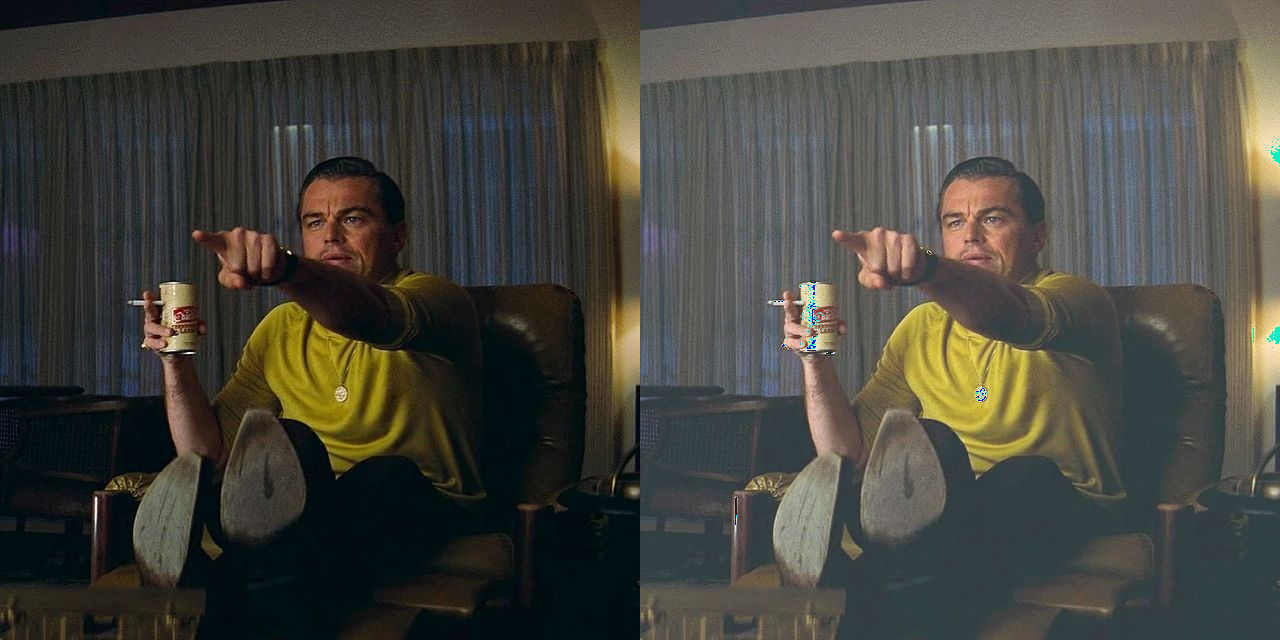

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/touch.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# Tugas Praktikum D1

## 1. Implementasi Invers Citra

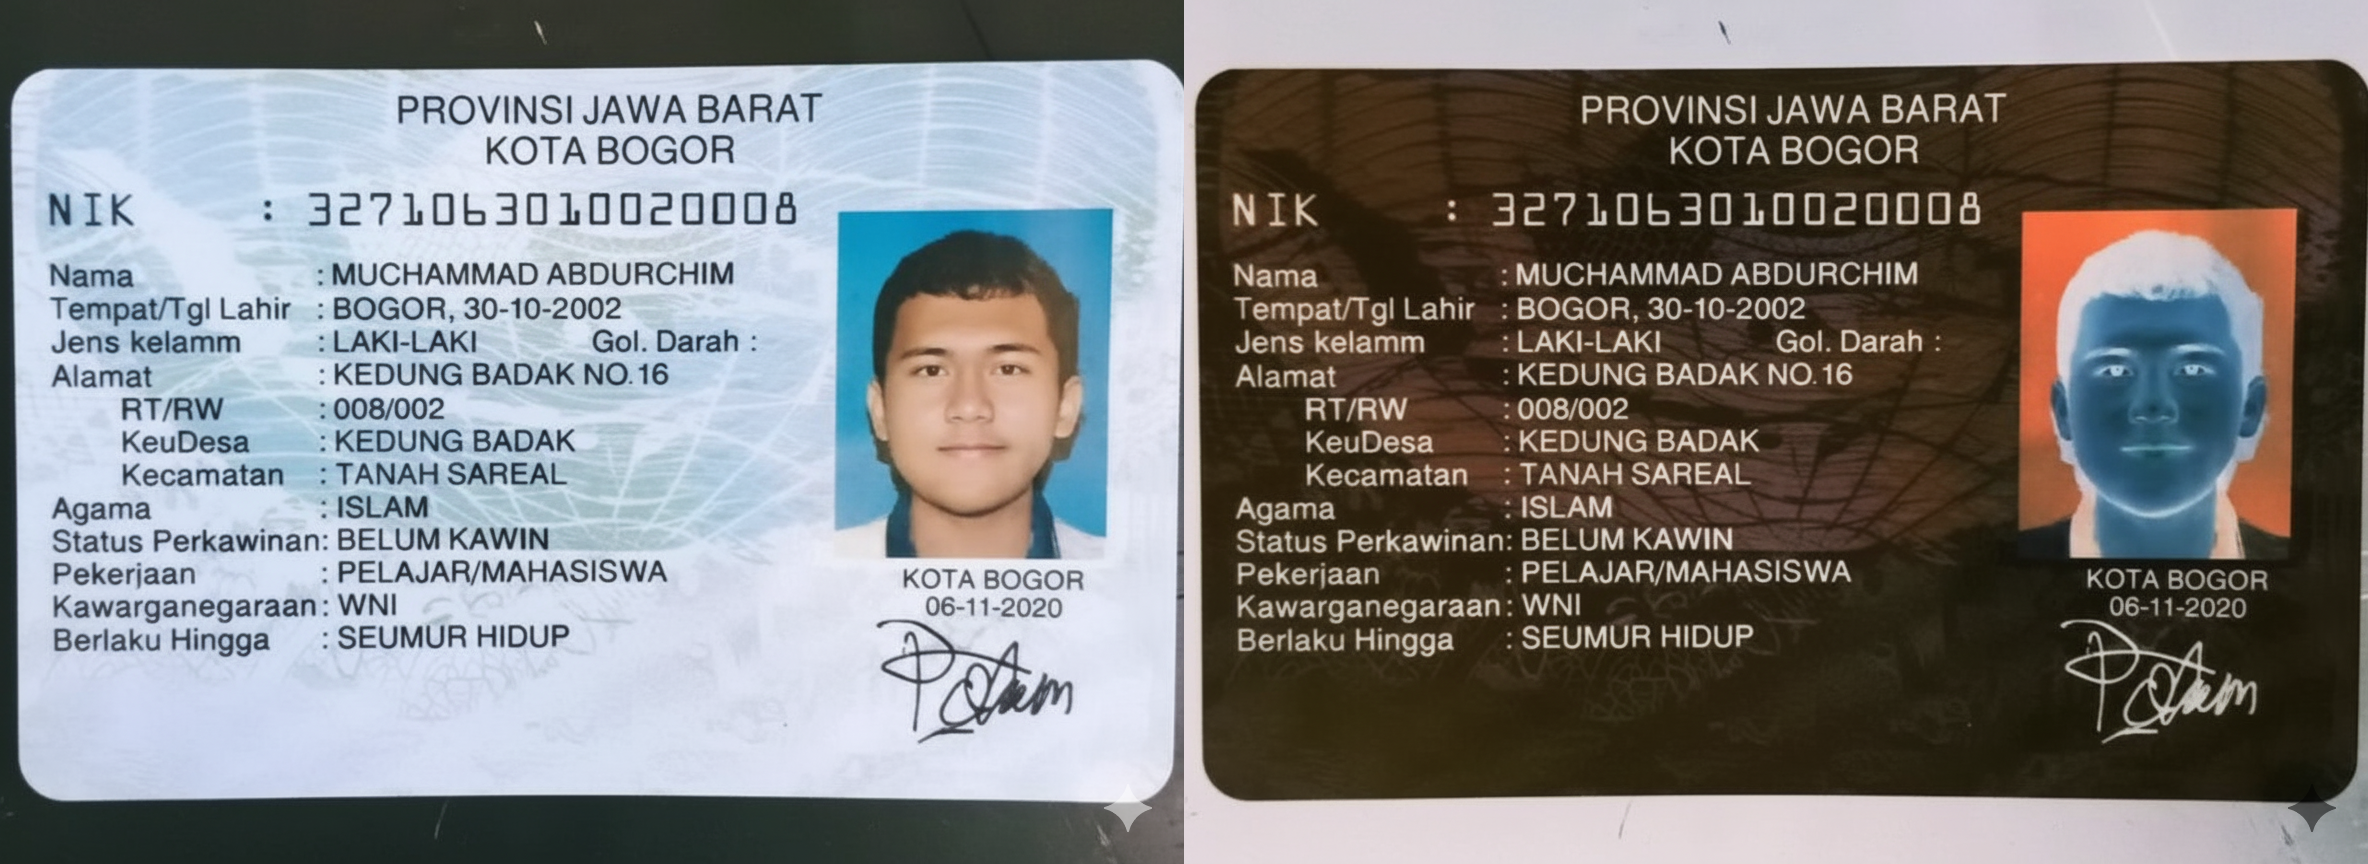

In [ ]:
original_image = cv.imread('/content/drive/MyDrive/PCVK/KTP_OHIM.png')

inverse_image = 255 - original_image

combined_image = cv.hconcat((original_image, inverse_image))
cv2_imshow(combined_image)

## 2. Implementasi Transformasi Contrast

 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan tingkat kecerahan [-255 - 255]: 20
Masukkan nilai kontras [1.0 - 3.0]: 2


/tmp/ipython-input-262321592.py:16: RuntimeWarning: overflow encountered in scalar multiply
  val = contrast * original[y, x, c] + brightness
/tmp/ipython-input-262321592.py:16: RuntimeWarning: overflow encountered in scalar add
  val = contrast * original[y, x, c] + brightness


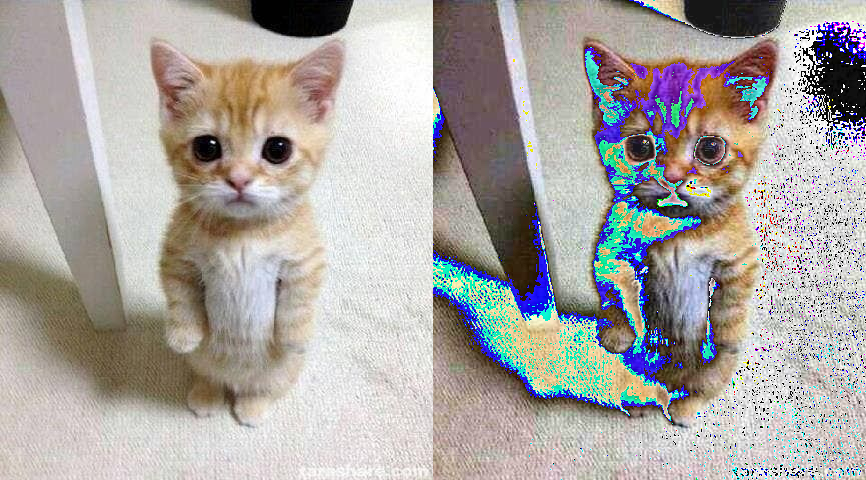

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan [-255 - 255]: '))
    contrast = int(input('Masukkan nilai kontras [1.0 - 3.0]: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/kitten01.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            val = contrast * original[y, x, c] + brightness
            brightness_image[y, x, c] = np.clip(val, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## Implementasi Transformasi Logarithmic Brightness

 Mengubah tingkat kecerahan citra 
------------------------------------


/tmp/ipython-input-4081128417.py:11: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(original))
/tmp/ipython-input-4081128417.py:11: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(original))


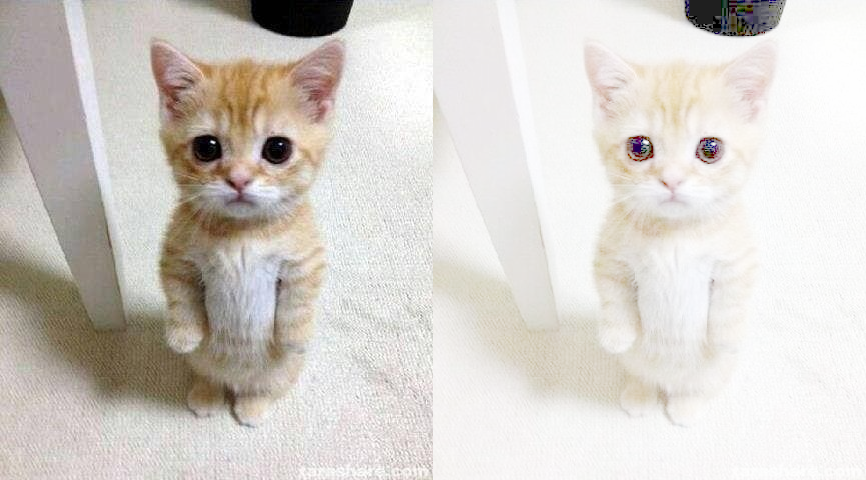

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    image = int(input('Masukkan tingkat kecerahan : '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/kitten01.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

c = 255 / np.log(1 + np.max(original))
log_image = c * (np.log1p(original.astype(np.float64)))

# tambahkan faktor brightness dari input
log_image = brightness * log_image

# normalisasi & ubah ke uint8
log_image = cv.normalize(log_image, None, 0, 255, cv.NORM_MINMAX)
log_image = np.uint8(log_image)

final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)